In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set(style="ticks")
RANDOM_STATE = 10

print("All libraries imported successfully.")


All libraries imported successfully.


In [ ]:
file_path = "heart.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError("heart.csv not found. Upload it into the Colab workspace.")

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget distribution:")
display(df['target'].value_counts())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal    

,count
target,
1,165
0,138


In [ ]:
print("Statistical Summary:")
display(df.describe())

print("\nObservations:")
print("- Check value ranges.")
print("- Ensure no unrealistic values exist.")


Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



Observations:
- Check value ranges.
- Ensure no unrealistic values exist.


In [ ]:
print("List of all columns:")
for col in df.columns:
    print(" -", col)

print("\nCategorical-like fields include: cp, thal, slope, sex, restecg, exang, fbs")
print("List of all columns:")
for col in df.columns:
    print(" -", col)

print("\nCategorical-like fields include: cp, thal, slope, sex, restecg, exang, fbs")


List of all columns:
 - age
 - sex
 - cp
 - trestbps
 - chol
 - fbs
 - restecg
 - thalach
 - exang
 - oldpeak
 - slope
 - ca
 - thal
 - target

Categorical-like fields include: cp, thal, slope, sex, restecg, exang, fbs
List of all columns:
 - age
 - sex
 - cp
 - trestbps
 - chol
 - fbs
 - restecg
 - thalach
 - exang
 - oldpeak
 - slope
 - ca
 - thal
 - target

Categorical-like fields include: cp, thal, slope, sex, restecg, exang, fbs


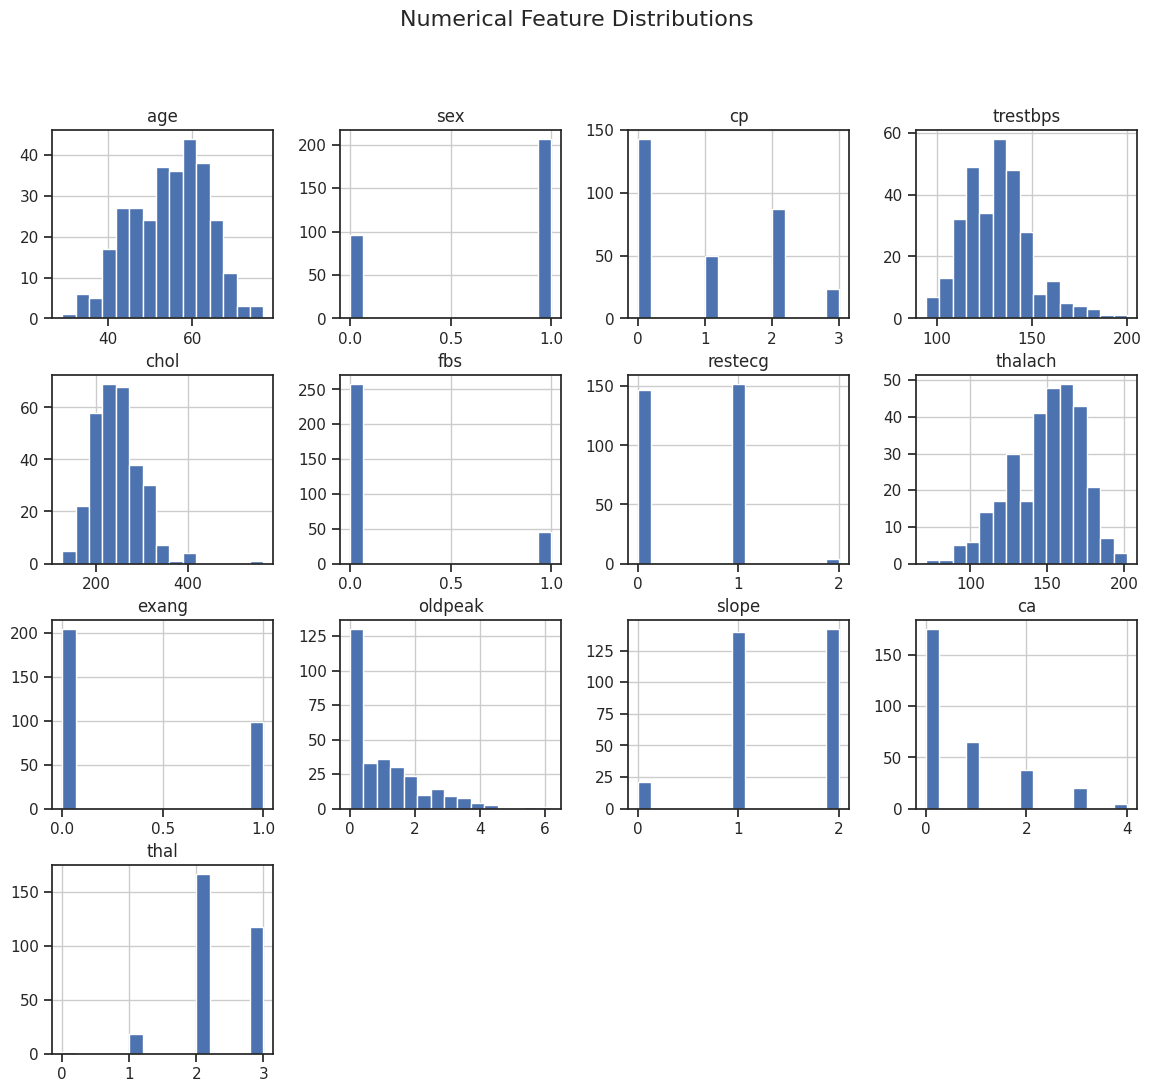

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "target" in num_cols:
    num_cols.remove("target")

df[num_cols].hist(figsize=(14,12), bins=15)
plt.suptitle("Numerical Feature Distributions", fontsize=16)
plt.show()


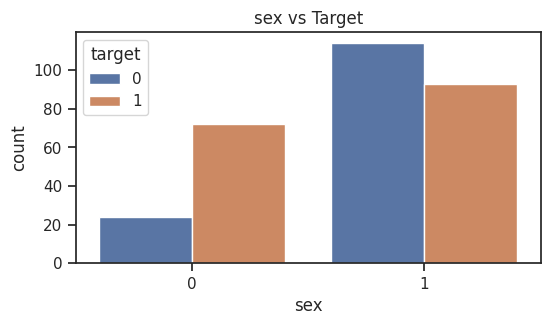

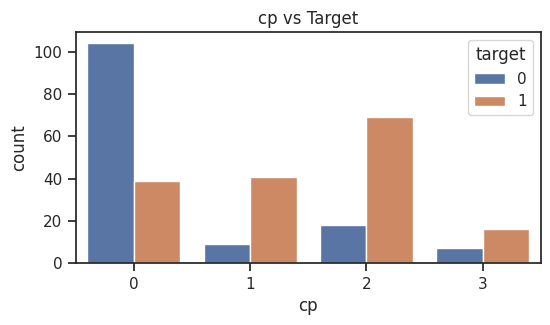

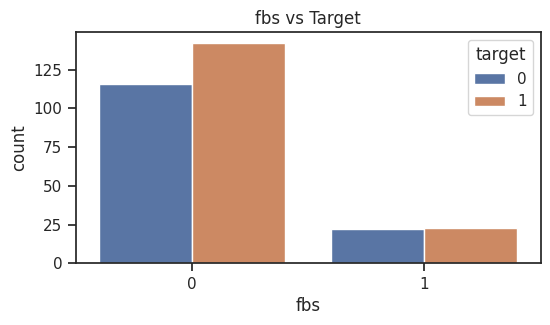

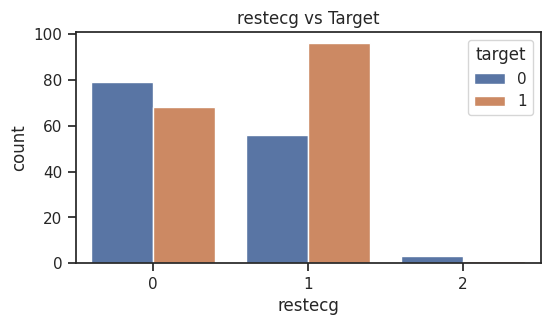

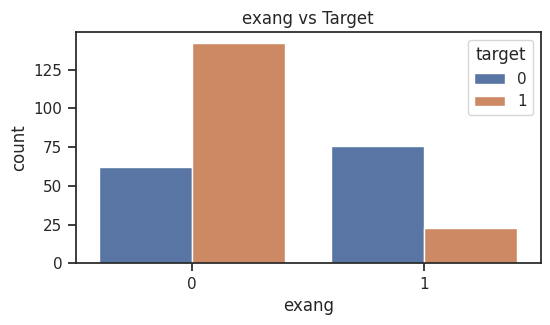

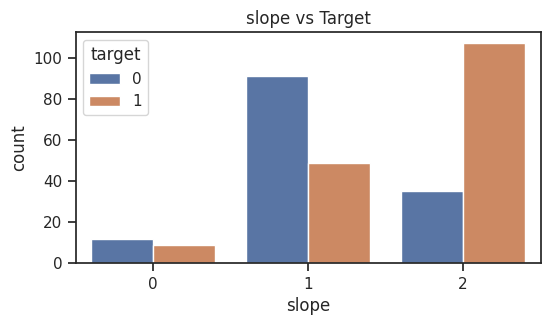

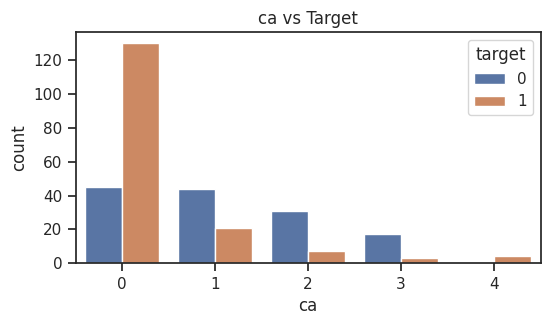

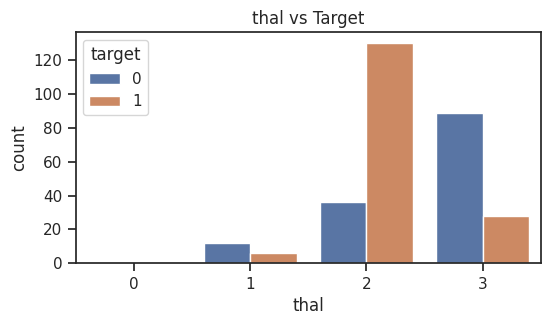

In [ ]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(6,3))
        sns.countplot(data=df, x=col, hue="target")
        plt.title(f"{col} vs Target")
        plt.show()


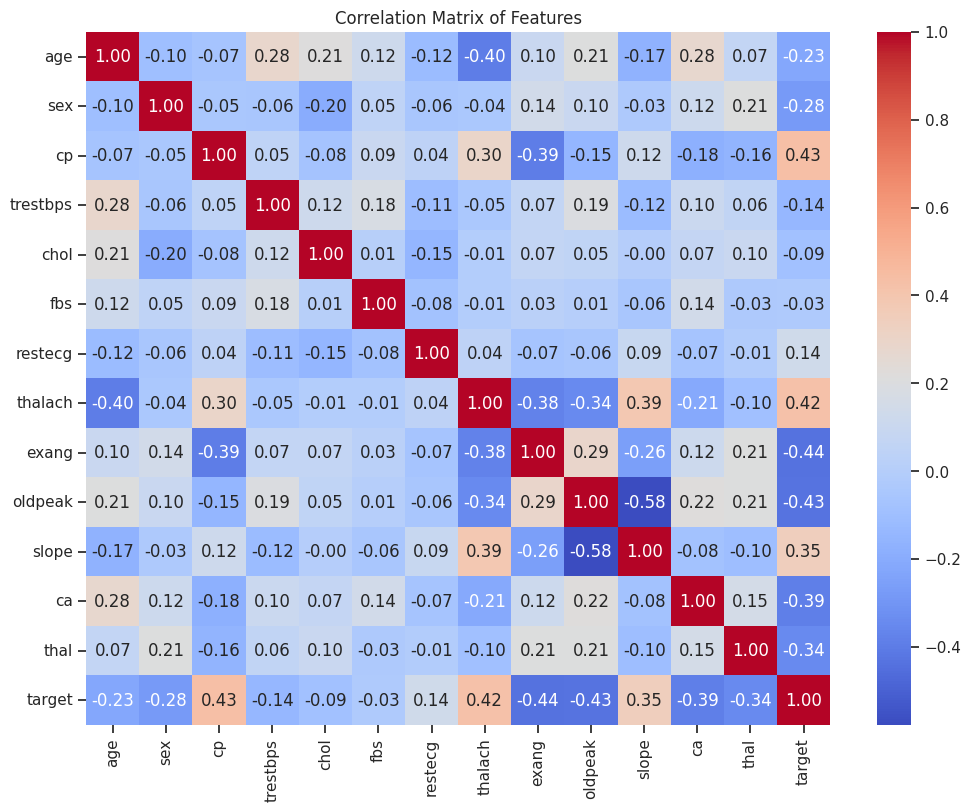

In [ ]:
plt.figure(figsize=(12,9))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()


In [ ]:
print("Checking for unusual entries:")

for col in df.columns:
    if df[col].dtype == object:
        print(f"{col}: {df[col].unique()}")

print("\nDataset appears numeric and clean. Proceeding with preprocessing.")


Checking for unusual entries:

Dataset appears numeric and clean. Proceeding with preprocessing.


In [ ]:
X = df.drop(columns=["target"])
y = df["target"]

# One-hot encoding categories
ohe_cols = ['cp', 'slope', 'thal']
numeric_cols = [c for c in X.columns if c not in ohe_cols]

print("Numeric Columns:", numeric_cols)
print("One-Hot Columns:", ohe_cols)

preprocess = ColumnTransformer([
    ("scale", StandardScaler(), numeric_cols),
    ("ohe", OneHotEncoder(drop="first", sparse_output=False), ohe_cols)
])

Numeric Columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'ca']
One-Hot Columns: ['cp', 'slope', 'thal']


In [ ]:
X_processed = preprocess.fit_transform(X)

print("Preprocessing completed.")
print("Processed feature shape:", X_processed.shape)


Preprocessing completed.
Processed feature shape: (303, 18)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (242, 18)
Testing samples: (61, 18)


In [ ]:
def evaluate(model, name):
    print(f"\n====== Evaluating {name} ======")

    y_pred = model.predict(X_test)
    if y_pred.dtype != int:
        y_pred = (y_pred > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    try:
        y_proba = model.predict_proba(X_test)[:,1]
    except:
        y_proba = model.predict(X_test).ravel()

    auc = roc_auc_score(y_test, y_proba)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("ROC-AUC:", auc)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return acc, prec, rec, f1, auc


In [ ]:
log_reg = LogisticRegression(max_iter=1200)
log_reg.fit(X_train, y_train)

lr_results = evaluate(log_reg, "Logistic Regression")



====== Evaluating Logistic Regression ======
Accuracy: 0.8688524590163934
Precision: 0.9032258064516129
Recall: 0.8484848484848485
F1: 0.875
ROC-AUC: 0.9285714285714286

Confusion Matrix:
[[25  3]
 [ 5 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        28
           1       0.90      0.85      0.88        33

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [ ]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

dt_results = evaluate(dt, "Decision Tree")



====== Evaluating Decision Tree ======
Accuracy: 0.6885245901639344
Precision: 0.6842105263157895
Recall: 0.7878787878787878
F1: 0.7323943661971831
ROC-AUC: 0.6796536796536795

Confusion Matrix:
[[16 12]
 [ 7 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.57      0.63        28
           1       0.68      0.79      0.73        33

    accuracy                           0.69        61
   macro avg       0.69      0.68      0.68        61
weighted avg       0.69      0.69      0.68        61



In [ ]:
rf_base = RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE)
rf_base.fit(X_train, y_train)

rf_base_results = evaluate(rf_base, "Random Forest (Base)")



====== Evaluating Random Forest (Base) ======
Accuracy: 0.7868852459016393
Precision: 0.8125
Recall: 0.7878787878787878
F1: 0.8
ROC-AUC: 0.8901515151515152

Confusion Matrix:
[[22  6]
 [ 7 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



In [ ]:
param_grid = {
    "n_estimators": [80,120,200],
    "max_depth": [None, 6, 10],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    rf, param_distributions=param_grid, n_iter=10,
    cv=5, scoring="roc_auc", n_jobs=-1, random_state=RANDOM_STATE
)

search.fit(X_train, y_train)

print("Best Parameters:", search.best_params_)

rf_tuned = search.best_estimator_

rf_tuned_results = evaluate(rf_tuned, "Random Forest (Tuned)")


Best Parameters: {'n_estimators': 80, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 6}

====== Evaluating Random Forest (Tuned) ======
Accuracy: 0.819672131147541
Precision: 0.8235294117647058
Recall: 0.8484848484848485
F1: 0.835820895522388
ROC-AUC: 0.9058441558441559

Confusion Matrix:
[[22  6]
 [ 5 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [ ]:
nn = Sequential([
    Dense(48, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.15),
    Dense(24, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = nn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=180,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

nn_results = evaluate(nn, "Neural Network")


Epoch 1/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4298 - loss: 0.7152 - val_accuracy: 0.6939 - val_loss: 0.6356
Epoch 2/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7069 - loss: 0.6368 - val_accuracy: 0.8163 - val_loss: 0.5894
Epoch 3/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7868 - loss: 0.5619 - val_accuracy: 0.8571 - val_loss: 0.5463
Epoch 4/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7679 - loss: 0.5307 - val_accuracy: 0.8367 - val_loss: 0.5117
Epoch 5/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7947 - loss: 0.5030 - val_accuracy: 0.8163 - val_loss: 0.4810
Epoch 6/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8031 - loss: 0.4903 - val_accuracy: 0.8367 - val_loss: 0.4581
Epoch 7/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8191 - loss: 0.4102 - val_accuracy: 0.8367 - val_loss: 0.4381
Epoch 8/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8029 - loss: 0.4485 - val_accuracy: 0.8367 - 

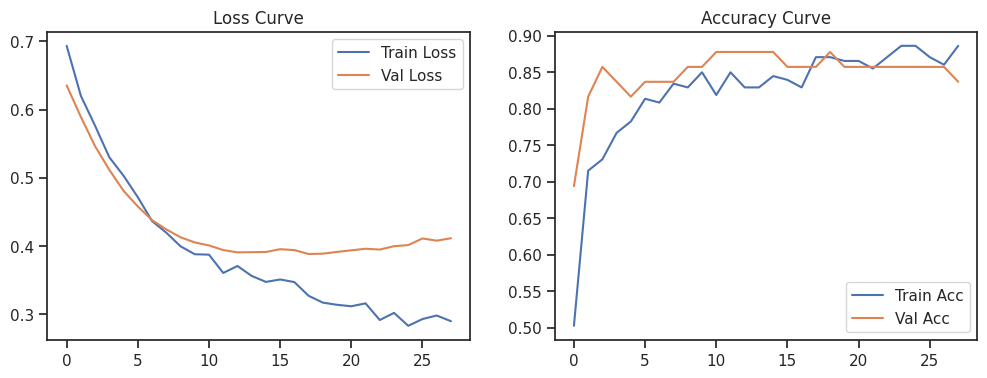

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()


In [ ]:
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "RF Base", "RF Tuned", "Neural Net"],
    "Accuracy": [lr_results[0], dt_results[0], rf_base_results[0], rf_tuned_results[0], nn_results[0]],
    "Precision": [lr_results[1], dt_results[1], rf_base_results[1], rf_tuned_results[1], nn_results[1]],
    "Recall": [lr_results[2], dt_results[2], rf_base_results[2], rf_tuned_results[2], nn_results[2]],
    "F1 Score": [lr_results[3], dt_results[3], rf_base_results[3], rf_tuned_results[3], nn_results[3]],
    "ROC-AUC": [lr_results[4], dt_results[4], rf_base_results[4], rf_tuned_results[4], nn_results[4]],
})

results_df.sort_values(by="ROC-AUC", ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,Neural Net,0.852459,0.900000,0.818182,0.857143,0.931818
0,Logistic Regression,0.868852,0.903226,0.848485,0.875000,0.928571
3,RF Tuned,0.819672,0.823529,0.848485,0.835821,0.905844
2,RF Base,0.786885,0.812500,0.787879,0.800000,0.890152
1,Decision Tree,0.688525,0.684211,0.787879,0.732394,0.679654


In [ ]:
# ==== CONFUSION MATRIX CELL ====

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def show_confusion_matrix(model, X_test, y_test, title="Confusion Matrix"):
    """
    Displays confusion matrix for any ML model.
    Automatically handles models that return probabilities.
    """
    # Get predictions
    try:
        y_pred = model.predict(X_test)
    except:
        # For Keras or models returning probabilities
        y_pred = (model.predict(X_test) > 0.5).astype(int)

    # Convert predictions
    if not isinstance(y_pred[0], (np.int32, np.int64, int)):
        y_pred = (y_pred > 0.5).astype(int)

    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\nConfusion Matrix Values:")
    print(cm)


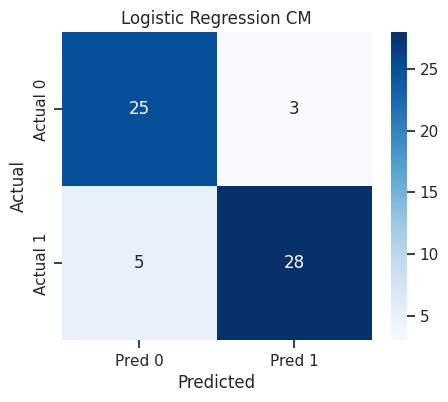


Confusion Matrix Values:
[[25  3]
 [ 5 28]]


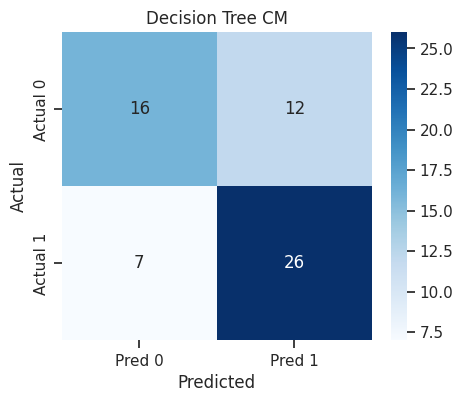


Confusion Matrix Values:
[[16 12]
 [ 7 26]]


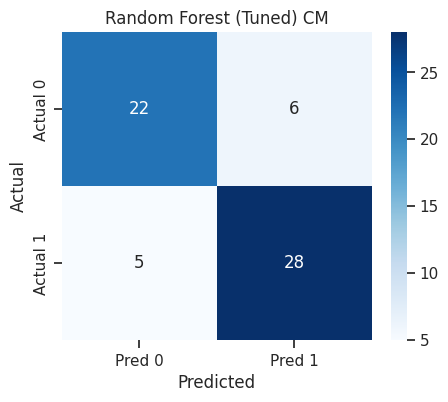


Confusion Matrix Values:
[[22  6]
 [ 5 28]]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


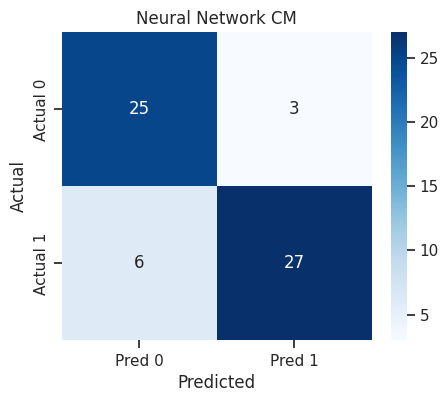


Confusion Matrix Values:
[[25  3]
 [ 6 27]]


In [ ]:
show_confusion_matrix(log_reg, X_test, y_test, "Logistic Regression CM")
show_confusion_matrix(dt, X_test, y_test, "Decision Tree CM")
show_confusion_matrix(rf_tuned, X_test, y_test, "Random Forest (Tuned) CM")
show_confusion_matrix(nn, X_test, y_test, "Neural Network CM")


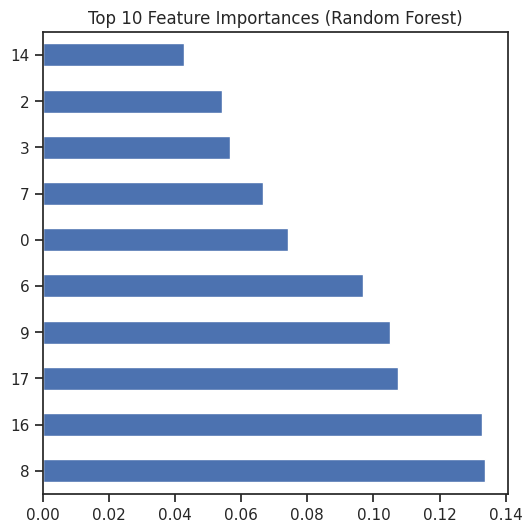

In [ ]:
try:
    rf_imp = pd.Series(rf_tuned.feature_importances_)
    plt.figure(figsize=(6,6))
    rf_imp.nlargest(10).plot(kind="barh")
    plt.title("Top 10 Feature Importances (Random Forest)")
    plt.show()
except:
    print("Feature importance extraction failed.")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


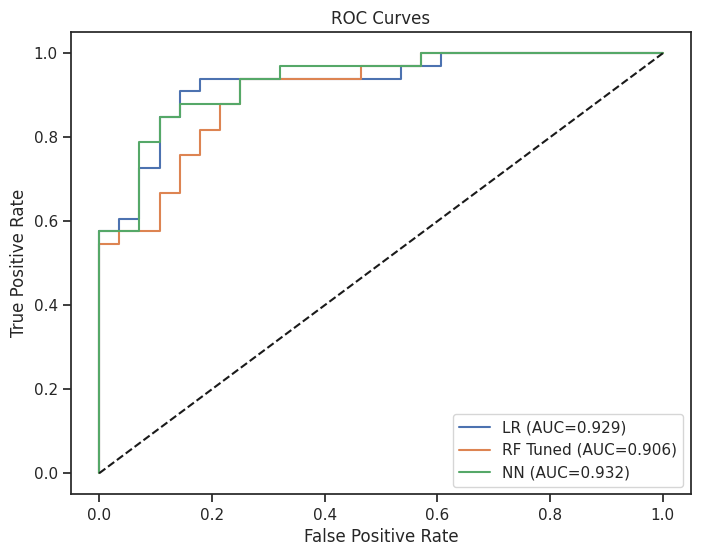

In [ ]:
def plot_roc_curve(model, name):
    try:
        y_proba = model.predict_proba(X_test)[:,1]
    except:
        y_proba = model.predict(X_test).ravel()

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.figure(figsize=(8,6))
plot_roc_curve(log_reg, "LR")
plot_roc_curve(rf_tuned, "RF Tuned")
plot_roc_curve(nn, "NN")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [ ]:
os.makedirs("saved_models_v2", exist_ok=True)

joblib.dump(log_reg, "saved_models_v2/log_reg_v2.joblib")
joblib.dump(rf_tuned, "saved_models_v2/rf_tuned_v2.joblib")
joblib.dump(preprocess, "saved_models_v2/preprocess_v2.joblib")

nn.save("saved_models_v2/neural_net_v2.h5")

print("Models saved successfully in folder: saved_models_v2")


Models saved successfully in folder: saved_models_v2


In [ ]:
print("===== PROJECT SUMMARY (STUDENT VERSION 2) =====")
print("1. Dataset loaded and explored thoroughly.")
print("2. Numerical + categorical features analyzed separately.")
print("3. Preprocessing applied: scaling + one-hot encoding.")
print("4. Models trained:")
print("   - Logistic Regression")
print("   - Decision Tree")
print("   - Random Forest (base and tuned)")
print("   - Neural Network (Keras)")
print("5. Evaluated using Accuracy, Precision, Recall, F1, ROC-AUC.")
print("6. Compared all models and plotted ROC curves.")
print("7. Extracted feature importances from RandomForest.")
print("8. Saved final models for future use.")
print("================================================")


===== PROJECT SUMMARY (STUDENT VERSION 2) =====
1. Dataset loaded and explored thoroughly.
2. Numerical + categorical features analyzed separately.
3. Preprocessing applied: scaling + one-hot encoding.
4. Models trained:
   - Logistic Regression
   - Decision Tree
   - Random Forest (base and tuned)
   - Neural Network (Keras)
5. Evaluated using Accuracy, Precision, Recall, F1, ROC-AUC.
6. Compared all models and plotted ROC curves.
7. Extracted feature importances from RandomForest.
8. Saved final models for future use.


In [ ]:
# ===========================================
# HEART DISEASE PREDICTION – GRADIO APP (HF Spaces Ready)
# ===========================================

!pip install gradio joblib -q

import gradio as gr
import pandas as pd
import joblib
from sklearn.pipeline import Pipeline

# Re-load the preprocessor and the best_rf model
preprocessor = joblib.load("saved_models_v2/preprocess_v2.joblib")
best_rf = joblib.load("saved_models_v2/rf_tuned_v2.joblib")

# Create a pipeline that includes preprocessing and the model
# The ColumnTransformer must be part of the pipeline to process raw inputs
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_rf)
])

# Save the pipeline so Gradio can load it by name
joblib.dump(model_pipeline, "saved_models_v2/best_random_forest_pipeline.joblib")
print("Saved saved_models_v2/best_random_forest_pipeline.joblib")

# Load saved RF pipeline
model = joblib.load("saved_models_v2/best_random_forest_pipeline.joblib")

def predict_heart_disease(age, sex, cp, trestbps, chol, fbs, restecg,
                          thalach, exang, oldpeak, slope, ca, thal):

    # Create input dataframe - ensure column order matches original X
    input_data = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal
    }])

    # Predict using saved pipeline (preprocessing is handled internally by the pipeline)
    proba = model.predict_proba(input_data)[0][1]
    label = int(proba >= 0.5)

    return {
        "Probability of Heart Disease": float(proba),
        "Prediction (0=No, 1=Yes)": label
    }


# Gradio UI - Simplified inputs to directly take numerical values
inputs = [
    gr.Number(label="Age"),
    gr.Radio([0, 1], label="Sex (0=Female, 1=Male)"),
    gr.Radio([0, 1, 2, 3], label="Chest Pain Type (cp)"),
    gr.Number(label="Resting BP (trestbps)"),
    gr.Number(label="Cholesterol (chol)"),
    gr.Radio([0, 1], label="Fasting Blood Sugar >120 mg/dl (0=False, 1=True)"),
    gr.Radio([0, 1, 2], label="Resting ECG (restecg)"),
    gr.Number(label="Max Heart Rate (thalach)"),
    gr.Radio([0, 1], label="Exercise Induced Angina (0=No, 1=Yes)"),
    gr.Number(label="ST Depression (oldpeak)"),
    gr.Radio([0, 1, 2], label="Slope of Peak Exercise ST Segment (slope)"),
    gr.Radio([0, 1, 2, 3, 4], label="Number of Major Vessels (ca)"),
    gr.Radio([0, 1, 2, 3], label="Thal (0,1=Normal, 2=Fixed Defect, 3=Reversible Defect)") # Correcting thal input based on EDA (0,1,2,3)
]

output = gr.JSON()

gr.Interface(
    fn=predict_heart_disease,
    inputs=inputs,
    outputs=output,
    title="Heart Disease Prediction App",
    description="A Machine Learning model predicting the probability of heart disease.",
    allow_flagging="never"
).launch(share=True)


Saved saved_models_v2/best_random_forest_pipeline.joblib
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a5eaf3d2527c259165.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
